In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
import logging

In [2]:
import tensorflow as tf
import tensorflow_datasets as tfds

print("TensorFlow versión:", tf.__version__)

TensorFlow versión: 2.18.1


In [3]:
logger = tf.get_logger()
logger.setLevel(logging.ERROR)

In [4]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)

train_dataset = dataset['train']
test_dataset  = dataset['test']

print("Dataset cargado correctamente.")
print("Entrenamiento:", metadata.splits['train'].num_examples, "imágenes")
print("Prueba:       ", metadata.splits['test'].num_examples,  "imágenes")

Dataset cargado correctamente.
Entrenamiento: 60000 imágenes
Prueba:        10000 imágenes


In [5]:
class_names = [
    'Cero', 'Uno', 'Dos', 'Tres', 'Cuatro',
    'Cinco', 'Seis', 'Siete', 'Ocho', 'Nueve'
]

In [6]:
num_train_examples = metadata.splits['train'].num_examples 
num_test_examples  = metadata.splits['test'].num_examples 

print(f"Ejemplos de entrenamiento: {num_train_examples}")
print(f"Ejemplos de prueba:        {num_test_examples}")

Ejemplos de entrenamiento: 60000
Ejemplos de prueba:        10000


In [7]:
def normalize(images, labels):
    """
    Normaliza los píxeles de 0-255 a 0-1.
    0 = blanco, 1 = negro
    """
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels

In [8]:
train_dataset = train_dataset.map(normalize)
test_dataset  = test_dataset.map(normalize)

print("Normalización aplicada correctamente.")

Normalización aplicada correctamente.


In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)), 
    tf.keras.layers.Dense(64, activation=tf.nn.relu), 
    tf.keras.layers.Dense(64, activation=tf.nn.relu), 
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)  
])

model.summary()

c:\Users\Diego\anaconda3\envs\notebook\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,050 (215.04 KB)

 Trainable params: 55,050 (215.04 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',   
    loss='sparse_categorical_crossentropy',  
    metrics=['accuracy']  
)

BATCHSIZE = 32

train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset  = test_dataset.batch(BATCHSIZE)

print(f"Modelo compilado. Tamaño de lote: {BATCHSIZE}")

Modelo compilado. Tamaño de lote: 32


In [11]:
history = model.fit(
    train_dataset,
    epochs=5,
    steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8558 - loss: 0.4943
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9611 - loss: 0.1327
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9729 - loss: 0.0928
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9781 - loss: 0.0702
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9821 - loss: 0.0573


In [12]:
test_loss, test_accuracy = model.evaluate(
    test_dataset,
    steps=math.ceil(num_test_examples / 32)
)

print(f"\nPérdida en pruebas:   {test_loss:.4f}")
print(f"Precisión en pruebas: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9773 - loss: 0.0793

Pérdida en pruebas:   0.0852
Precisión en pruebas: 0.9754 (97.54%)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step


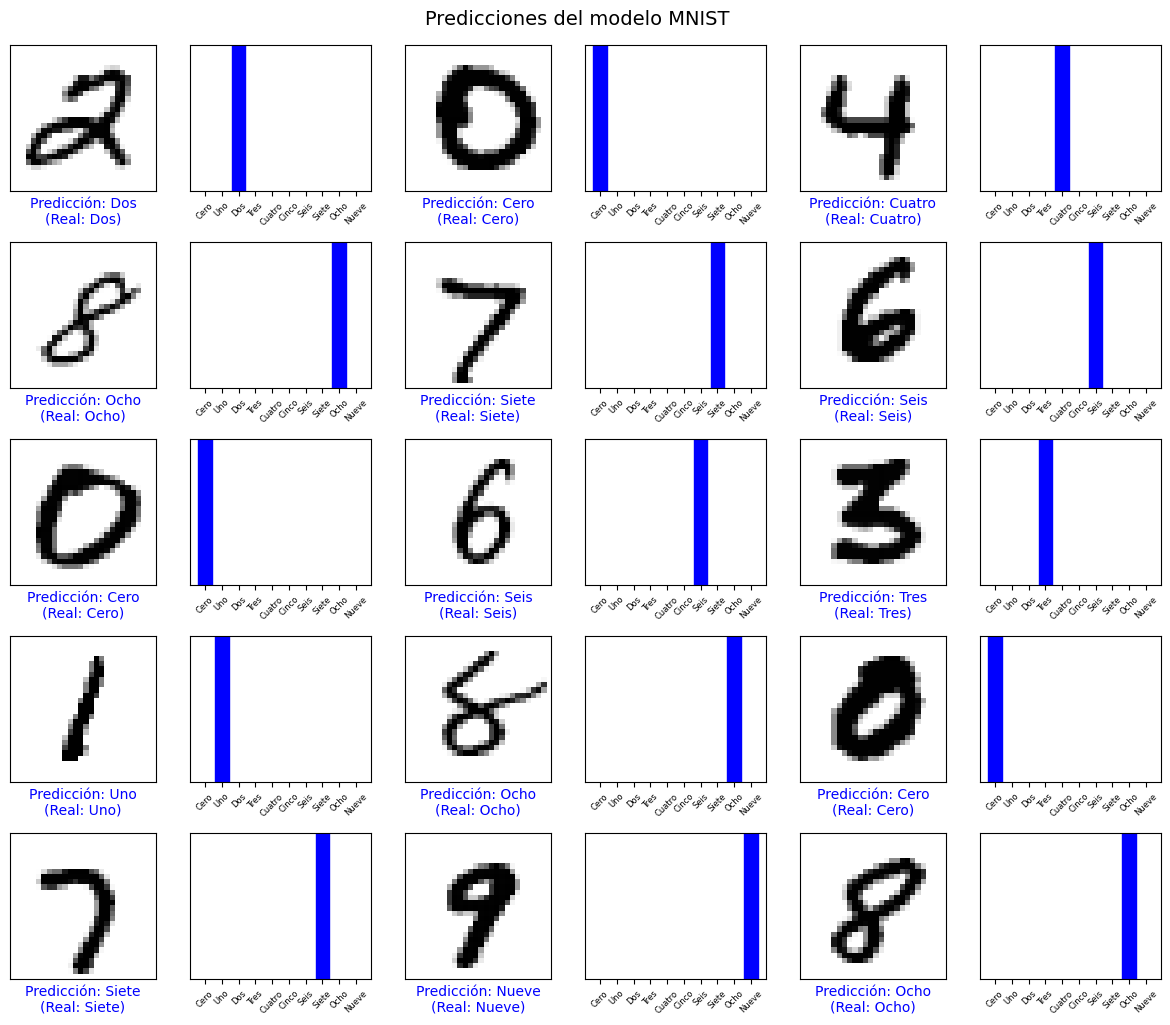

Gráfico guardado como 'predicciones_mnist.png'


In [13]:
for test_images, test_labels in test_dataset.take(1):
    test_images = test_images.numpy()
    test_labels = test_labels.numpy()
    predictions = model.predict(test_images)

def plot_image(i, predictions_array, true_labels, images):
    """Muestra la imagen con la predicción (azul=correcto, rojo=incorrecto)."""
    predictions_array = predictions_array[i]
    true_label        = true_labels[i]
    img               = images[i]

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img[..., 0], cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    color = 'blue' if predicted_label == true_label else 'red'

    plt.xlabel(
        f"Predicción: {class_names[predicted_label]}\n(Real: {class_names[true_label]})",
        color=color
    )

def plot_value_array(i, predictions_array, true_label):
    """Muestra el gráfico de barras de probabilidades por clase."""
    predictions_array = predictions_array[i]
    true_label        = true_label[i]

    plt.grid(False)
    plt.xticks(range(10), class_names, rotation=45, fontsize=6)
    plt.yticks([])

    thisplot = plt.bar(range(10), predictions_array, color="#888888")
    plt.ylim([0, 1])

    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')

# Visualizar las primeras 15 predicciones
num_rows = 5
num_cols = 3
num_images = num_rows * num_cols

plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))

for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, test_labels, test_images)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, test_labels)

plt.tight_layout()
plt.suptitle("Predicciones del modelo MNIST", fontsize=14, y=1.02)
plt.savefig('predicciones_mnist.png', bbox_inches='tight')
plt.show()
print("Gráfico guardado como 'predicciones_mnist.png'")

In [21]:
html_content = """
<!DOCTYPE html>
<html>
<head>
    <title>Reconocimiento de Numeros</title>
    <script src="https://code.jquery.com/jquery-3.4.1.min.js"
            integrity="sha256-CSXorXvZcTkaix6Yvo6HppcZGetbYMGWSFlBw8HfCJo="
            crossorigin="anonymous"></script>
</head>
<body>
    <h2>Dibuja un numero del 0 al 9</h2>
    <canvas id="canvas" width="280" height="280" 
            style="border:2px solid black; cursor:crosshair; background:black;">
    </canvas>
    <br><br>
    <button onclick="limpiar()">Limpiar</button>
    <button onclick="predecir()">Predecir</button>
    <h1 id="resultado">-</h1>

    <script>
        var canvas = document.getElementById('canvas');
        var ctx = canvas.getContext('2d');
        var dibujando = false;

        ctx.strokeStyle = 'white';
        ctx.lineWidth = 35;
        ctx.lineCap = 'round';

        canvas.onmousedown = function(e) {
            dibujando = true;
            ctx.beginPath();
            ctx.moveTo(e.offsetX, e.offsetY);
        }

        canvas.onmousemove = function(e) {
            if (!dibujando) return;
            ctx.lineTo(e.offsetX, e.offsetY);
            ctx.stroke();
        }

        canvas.onmouseup   = function() { dibujando = false; }
        canvas.onmouseleave = function() { dibujando = false; }

        function limpiar() {
            ctx.clearRect(0, 0, 280, 280);
            ctx.fillStyle = 'black';
            ctx.fillRect(0, 0, 280, 280);
            document.getElementById('resultado').innerHTML = '-';
        }

        function predecir() {
            // Escalar canvas a 28x28
            var tmpCanvas = document.createElement('canvas');
            tmpCanvas.width = 28;
            tmpCanvas.height = 28;
            var tmpCtx = tmpCanvas.getContext('2d');
            tmpCtx.imageSmoothingEnabled = true;
            tmpCtx.imageSmoothingQuality = 'high';
            tmpCtx.drawImage(canvas, 0, 0, 28, 28);

            // Obtener pixeles igual que en el PDF
            var pixels = [];
            var imageData = tmpCtx.getImageData(0, 0, 28, 28);
            var data = imageData.data;
            for (var i = 0; i < 28 * 28; i++) {
                var color = data[i * 4] / 255;
                color = (Math.round(color * 100) / 100).toFixed(2);
                pixels.push(color);
            }

            // Enviar al servidor Python
            $.post("http://localhost:8000", {pixeles: pixels.join(",")},
                function(response) {
                    document.getElementById('resultado').innerHTML = 
                        "Prediccion: " + response;
                }
            );
        }
    </script>
</body>
</html>
"""

with open('index.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("index.html creado")

index.html creado


In [15]:
from urllib import parse
from http.server import HTTPServer, BaseHTTPRequestHandler

print("Librerías del servidor HTTP importadas.")

Librerías del servidor HTTP importadas.


In [16]:
class SimpleHTTPRequestHandler(BaseHTTPRequestHandler):
    """Manejador de solicitudes HTTP POST para procesar píxeles con la red neuronal."""

    def log_message(self, format, *args):
        """Silencia los logs del servidor para no saturar la consola."""
        pass

    def do_POST(self):
        print("\n Petición POST recibida")

        try:
            # ── 1. Leer y limpiar los datos recibidos ──────────────
            content_length = int(self.headers['Content-Length'])
            data = self.rfile.read(content_length)
            data = data.decode()
            data = data.replace('pixeles=', '')
            data = parse.unquote(data)

            # ── 2. Transformar al formato que espera el modelo ─────
            # El canvas envía 784 valores (28x28), igual que MNIST
            arr = np.fromstring(data, np.float32, sep=",")

            if arr.shape[0] != 784:
                raise ValueError(f"Se esperaban 784 píxeles, se recibieron {arr.shape[0]}")

            arr = arr.reshape(28, 28)
            arr = np.array(arr)
            arr = arr.reshape(1, 28, 28, 1)  # Formato: (batch, alto, ancho, canales)

            # ── 3. Realizar la predicción ─────────────────────────
            prediction_values = model.predict(arr, batch_size=1, verbose=0)
            prediction_idx    = int(np.argmax(prediction_values))
            prediction_str    = str(prediction_idx)

            nombres = ['Cero','Uno','Dos','Tres','Cuatro','Cinco','Seis','Siete','Ocho','Nueve']
            confianza = float(np.max(prediction_values)) * 100

            print(f"   Predicción: {prediction_idx} ({nombres[prediction_idx]}) – Confianza: {confianza:.1f}%")

            # ── 4. Enviar respuesta al cliente ────────────────────
            self.send_response(200)
            self.send_header("Access-Control-Allow-Origin", "*")  # Evitar problemas CORS
            self.send_header("Content-Type", "text/plain")
            self.end_headers()
            self.wfile.write(prediction_str.encode())

        except Exception as e:
            print(f"   Error: {e}")
            self.send_response(500)
            self.send_header("Access-Control-Allow-Origin", "*")
            self.end_headers()
            self.wfile.write(b"-1")

    def do_OPTIONS(self):
        """Maneja preflight CORS para evitar bloqueos en el navegador."""
        self.send_response(200)
        self.send_header("Access-Control-Allow-Origin",  "*")
        self.send_header("Access-Control-Allow-Methods", "POST, OPTIONS")
        self.send_header("Access-Control-Allow-Headers", "Content-Type")
        self.end_headers()

print("Clase SimpleHTTPRequestHandler definida correctamente.")

Clase SimpleHTTPRequestHandler definida correctamente.


In [ ]:
PUERTO = 8000

print(f" Iniciando servidor HTTP en http://localhost:{PUERTO}")
print("   Abre el archivo 'index.html' en tu navegador.")
print("   Para detener el servidor: Kernel → Interrupt Kernel (o Ctrl+C)\n")

try:
    server = HTTPServer(('localhost', PUERTO), SimpleHTTPRequestHandler)
    server.serve_forever()
except KeyboardInterrupt:
    print("\n Servidor detenido por el usuario.")
    server.server_close()

 Iniciando servidor HTTP en http://localhost:8000
   Abre el archivo 'index.html' en tu navegador.
   Para detener el servidor: Kernel → Interrupt Kernel (o Ctrl+C)

